c:\Users\kdivy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 3505/3506 [03:31<00:00]        

raw shap_values shape: (1753, 21, 2)
X_test shape: (1753, 21)


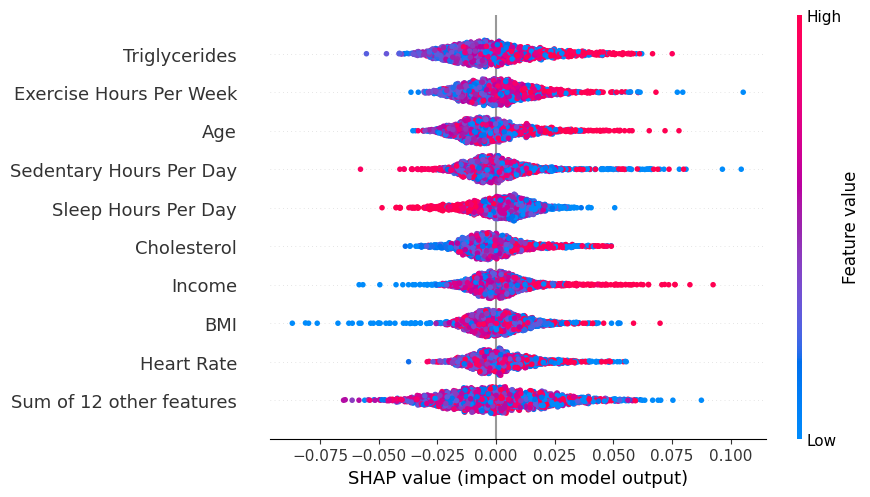

In [1]:
# SHAP ANALYSIS FOR RANDOM FOREST

import pandas as pd
import matplotlib.pyplot as plt
import shap
from shap import Explanation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1) LOAD & PREPARE DATA
df = pd.read_csv(r'C:\Users\kdivy\OneDrive\Desktop\COMP ANA HT DATA\COMP HT project\heart_attack_prediction_dataset.csv')

# Drop non‐feature columns, keep target
X = df.drop(columns=['Patient ID', 'Country', 'Continent', 'Hemisphere', 'Heart Attack Risk'])
y = df['Heart Attack Risk']

# Ensure numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Train/test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) TRAIN RANDOM FOREST

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


# 3) COMPUTE SHAP EXPLANATIONS
# Use the new SHAP API
explainer = shap.Explainer(rf, X_test)        # links model + data
shap_values = explainer(X_test)               # returns an Explanation object

# Confirm shapes
print("raw shap_values shape:", shap_values.values.shape)  # (n_samples, n_features, n_classes)
print("X_test shape:", X_test.shape)                       # should be (n_samples, n_features)


# 4) EXTRACT CLASS-1 EXPLANATION
# For binary classification, index 1 = heart‐attack risk
vals_class1  = shap_values.values[:, :, 1]  
base_class1  = shap_values.base_values[1]  

# Build a new Explanation for class-1 only
exp_class1 = Explanation(
    values       = vals_class1,
    base_values  = base_class1,
    data         = X_test.to_numpy(),       
    feature_names= list(X_test.columns)
)

# 5) SHAP BEESWARM PLOT (class 1)
plt.figure(figsize=(10,6))
shap.plots.beeswarm(exp_class1)
plt.show()
